# Fixed-Point Quantization Testbed

This notebook evaluates model performance under different fixed-point quantization bit-widths.

**Key Metrics:**
- ROC curves
- AUC (Area Under Curve)
- TPR at FPR = 1e-5

**Quantization formats tested:**
- Float32 (baseline)
- Various fixed-point: Q<I>.<F> where I=integer bits, F=fractional bits

In [1]:
# Imports
import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# Set up paths
sys.path.insert(0, os.path.abspath('..'))

from cascaded_tn.quantization import QuantizationTestbed
from cascaded_tn.training.cascaded_model import CascadedModel, create_trainable_autoencoder
from tn4ml.embeddings import embed, TrigonometricEmbedding, ParticleVectorEmbedding
from tn4ml.eval import get_roc_curve_data
from tn4ml.metrics import TransformedNorm

import quimb.tensor as qtn

# Configure JAX
jax.config.update("jax_enable_x64", False)
jax.config.update('jax_default_matmul_precision', 'float32')

print("✅ Imports successful")

✅ Imports successful


## 1. Load or Create Model

In [2]:
# Load trained model
model_dir = '../models_to_share/fromPrajita/SMPO_best'
# model_dir = '../output/Reorder_Compress_19_7_1_bd2_2_hub15_center_out'
model_name = 'final_best_model.pkl'
model_path = model_dir + '/' + model_name
autoencoder = CascadedModel.load(model_path)
print(f"✅ Loaded trained model from {model_path}")
print(f"   Parameters: {autoencoder.nparams():,}")

print(f"✅ Model ready")
print(f"   Architecture: {[op.config.input_dim for op in autoencoder.cascade.operators]} → {autoencoder.cascade.operators[-1].config.output_dim}")
print(f"   Parameters: {autoencoder.nparams():,}")
autoencoder.summary()

[LOADING] Model from ../models_to_share/fromPrajita/SMPO_best/final_best_model.pkl
  - 936 parameters
  - 1 layers


[LOADED] Successfully loaded model
✅ Loaded trained model from ../models_to_share/fromPrajita/SMPO_best/final_best_model.pkl
   Parameters: 936
✅ Model ready
   Architecture: [19] → 1
   Parameters: 936

CASCADED MODEL SUMMARY

CASCADE SUMMARY: OpenAutoencoder_19to1
Architecture: 19 → 1

Layers: 1
  0: Unified↓(19→1, χ=4) (bottleneck)


Training Configuration:
  Strategy: global
  Optimizer: <function adam at 0x7f17828d8680>
  Learning rate: 0.01
  Loss function: None
  Training type: 0

Total parameters: 936

Parameters by layer:
  Layer 0 (Unified↓(19→1, χ=4)): 936 parameters



In [3]:
import numpy as np
import jax


def export_cascade_weights(autoencoder, output_path, layer_sites, layer_output_inds=None):
    """
    Export cascade weights to C++ header.
    
    Args:
        autoencoder: Trained CascadedModel
        output_path: Path to write weights.h
        layer_sites: List of sites per layer, e.g., [19, 2] for 19->2->1
        layer_output_inds: List of sets, one per layer, specifying which site
                          indices carry output physical indices.
                          e.g., [{0, 18}, {1}] for 19->2->1
                          If None, inferred from spacing (first/last + evenly spaced).
    """
    
    def extract_layer(start_idx, num_sites, output_inds):
        """Extract one SMPO layer starting at start_idx."""
        all_tensors = [np.array(jax.device_get(autoencoder.arrays[start_idx + i])) 
                       for i in range(num_sites)]
        
        # Detect bond and physical dimensions from tensor shapes
        max_bond = 1
        phys_in = 1
        phys_out = 1
        
        for idx, tensor in enumerate(all_tensors):
            shape = tensor.shape
            is_output = idx in output_inds
            is_left = idx == 0
            is_right = idx == num_sites - 1
            
            if is_left or is_right:
                # Edge sites: one bond dimension
                if is_output:
                    # (bond, pin, pout)
                    max_bond = max(max_bond, shape[0])
                    phys_in = max(phys_in, shape[1])
                    phys_out = max(phys_out, shape[2])
                else:
                    # (bond, pin)
                    max_bond = max(max_bond, shape[0])
                    phys_in = max(phys_in, shape[1])
            else:
                # Interior sites: two bond dimensions
                if is_output:
                    # (L, R, pin, pout)
                    max_bond = max(max_bond, shape[0], shape[1])
                    phys_in = max(phys_in, shape[2])
                    phys_out = max(phys_out, shape[3])
                else:
                    # (L, R, pin)
                    max_bond = max(max_bond, shape[0], shape[1])
                    phys_in = max(phys_in, shape[2])
        
        # Create dense weight array
        weights = np.zeros((num_sites, phys_in, phys_out, max_bond, max_bond),
                           dtype=np.float32)
        
        for site_idx in range(num_sites):
            tensor = all_tensors[site_idx]
            is_output = site_idx in output_inds
            is_left = site_idx == 0
            is_right = site_idx == num_sites - 1
            
            if is_left:
                if is_output:
                    # (bond, pin, pout) → weights[pin, pout, 0, bond]
                    transposed = np.transpose(tensor, (1, 2, 0))  # (pin, pout, bond)
                    weights[site_idx, :, :, 0, :transposed.shape[2]] = transposed
                else:
                    # (bond, pin) → weights[pin, 0, 0, bond]
                    weights[site_idx, :, 0, 0, :tensor.shape[0]] = tensor.T
            elif is_right:
                if is_output:
                    # (bond_left, pin, pout) → weights[pin, pout, bond_left, 0]
                    transposed = np.transpose(tensor, (1, 2, 0))  # (pin, pout, bond_left)
                    weights[site_idx, :, :, :transposed.shape[2], 0] = transposed
                else:
                    # (bond_left, pin) → weights[pin, 0, bond_left, 0]
                    weights[site_idx, :, 0, :tensor.shape[0], 0] = tensor.T
            else:
                if is_output:
                    # (L, R, pin, pout) → weights[pin, pout, L, R]
                    weights[site_idx, :, :, :, :] = np.transpose(tensor, (2, 3, 0, 1))
                else:
                    # (L, R, pin) → weights[pin, 0, L, R]
                    transposed = np.transpose(tensor, (2, 0, 1))  # (pin, L, R)
                    weights[site_idx, :, 0, :, :] = transposed
        
        return weights
    
    # Infer output_inds if not provided
    if layer_output_inds is None:
        layer_output_inds = []
        for num_sites in layer_sites:
            # Default: assume uniform spacing, first and last are always outputs
            # This is a fallback; explicit specification is preferred
            layer_output_inds.append({0, num_sites - 1})
            print(f"Warning: output_inds not provided, defaulting to {{0, {num_sites - 1}}}")
    
    # Extract all layers
    layers = []
    tensor_idx = 0
    for num_sites, output_inds in zip(layer_sites, layer_output_inds):
        layer_weights = extract_layer(tensor_idx, num_sites, output_inds)
        layers.append(layer_weights)
        nonzero = np.count_nonzero(layer_weights)
        total = layer_weights.size
        print(f"Layer {len(layers)}: {nonzero} non-zero elements "
              f"(shape {layer_weights.shape}, output sites: {sorted(output_inds)})")
        tensor_idx += num_sites
    
    # Write C++ header
    write_cpp_header(layers, output_path)
    print(f"Wrote weights to {output_path}")


def write_cpp_header(layers, output_path):
    """Write arbitrary number of layers to C++ header."""
    with open(output_path, 'w') as f:
        f.write("// Auto-generated weights file\n")
        f.write("// DO NOT EDIT MANUALLY\n\n")
        f.write("#ifndef WEIGHTS_H\n")
        f.write("#define WEIGHTS_H\n\n")
        f.write('#include "defines.h"\n\n')
        
        for layer_num, weights in enumerate(layers, 1):
            sites, phys_in, phys_out, left_bond, right_bond = weights.shape
            
            f.write(f"// Layer {layer_num} weights: [{sites}][{phys_in}][{phys_out}]"
                    f"[{left_bond}][{right_bond}]\n")
            f.write(f"const data_t weights{layer_num}_data[{sites}][{phys_in}]"
                    f"[{phys_out}][{left_bond}][{right_bond}] = {{\n")
            
            for i in range(sites):
                f.write("  { // Site %d\n" % i)
                for pin in range(phys_in):
                    f.write("    { // phys_in=%d\n" % pin)
                    for pout in range(phys_out):
                        f.write("      { // phys_out=%d\n" % pout)
                        for l in range(left_bond):
                            f.write("        {")
                            for r in range(right_bond):
                                f.write("%.16ff" % weights[i, pin, pout, l, r])
                                if r < right_bond - 1:
                                    f.write(", ")
                            f.write("}")
                            if l < left_bond - 1:
                                f.write(",\n")
                            else:
                                f.write("\n")
                        f.write("      }")
                        if pout < phys_out - 1:
                            f.write(",\n")
                        else:
                            f.write("\n")
                    f.write("    }")
                    if pin < phys_in - 1:
                        f.write(",\n")
                    else:
                        f.write("\n")
                f.write("  }")
                if i < sites - 1:
                    f.write(",\n")
                else:
                    f.write("\n")
            
            f.write("};\n\n")
        
        f.write("#endif // WEIGHTS_H\n")

In [4]:
export_cascade_weights(autoencoder, 
                       "../TN_HLS/test-weights-19-1.h", 
                       layer_sites=[19],
                       layer_output_inds=[{9}])

Layer 1: 936 non-zero elements (shape (19, 3, 3, 4, 4), output sites: [9])
Wrote weights to ../TN_HLS/test-weights-19-1.h


## 2. Set Up Embedding and Metric Function

In [7]:
# Set up embedding (use the same one from training)
embedding = ParticleVectorEmbedding(normalize=False)

# Define target loss (adjust based on your training)
target_loss = 50.0

# Define the anomaly score function)
def InputsToNorm(model, data):
    """Norm itself"""
    x = TransformedNorm(model, data)
    return x

@jax.jit
def ComputeNorm(data, targets, *params):
    """Compute the norm."""
    temp_model = autoencoder.copy()
    for tensor, param in zip(temp_model.tensors, params):
        tensor.modify(data=param)
    
    tn_i = embed(data, embedding)
    
    return InputsToNorm(temp_model, tn_i)

# Vectorize for batch processing
norm_term = jax.jit(jax.vmap(ComputeNorm, in_axes=[0, None] + [None]*autoencoder.L), backend='gpu')

print("✅ Metric function ready")

✅ Metric function ready


## 3. Create Data Loaders

In [8]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
ordering = np.load("optimal_ordering.npy")
signal_loaders = {
    'Ato4l': d.load_data(inputPath + "Ato4l_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True, particle_ordering=ordering),
    'LQ': d.load_data(inputPath + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True, particle_ordering=ordering),
    'hToTauNu': d.load_data(inputPath + "hChToTauNu_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True, particle_ordering=ordering),
    'hToTauTau': d.load_data(inputPath + "hToTauTau_13TeV_PU20.h5", batch_size=10000, shuffle=False, skip_MET_eta=False, norm=True, particle_ordering=ordering),
}

In [9]:
# Schedule data loading
import utils.dataloader as d
inputPath = "/lus/eagle/projects/ATLAS_workflow_ALCF/sagar/QiML/"
batch_size = 10000
background_train, background_val, background_test = d.create_split_dataloaders(
    file_path=inputPath+"background_for_training.h5",
    batch_size=batch_size,
    split_ratios=(0.70, 0.05, 0.25),
    norm=True,
    skip_MET_eta=False,
    shuffle=False,
    particle_ordering=ordering
)

[DATASET SPLITS]
  Total samples: 4,000,000
  Train: 2,800,000 (70.0%)
  Val:   200,000 (5.0%)
  Test:  1,000,000 (25.0%)

[DATALOADERS CREATED]
  Train batches: 280
  Val batches:   20
  Test batches:  100


In [ ]:
test_event = next(iter(background_test))[0]
test_event_np = np.array(test_event)

/tmp/ipykernel_1237057/2717125448.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_event_np = np.array(test_event)


In [ ]:
print(test_event_np)
input_mps = embed(test_event, embedding)

[0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.03140972 0.30378414 0.18589457
 0.03341232 0.5        0.66172858 0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5        0.         0.5        0.5
 0.         0.5        0.5       ]


In [ ]:
total_norm = 1.
for site in range(int(len(test_event_np)/3)):
   norm_site = 0
   for index in range(3):
      norm_site += test_event_np[3*site+index]*test_event_np[3*site+index]
   print("norm of this site ", site, " is ", norm_site)
   total_norm *= norm_site
print("total norm is ", total_norm**.5)

norm of this site  0  is  0.5
norm of this site  1  is  0.5
norm of this site  2  is  0.5
norm of this site  3  is  0.5
norm of this site  4  is  0.5
norm of this site  5  is  0.5
norm of this site  6  is  0.5
norm of this site  7  is  0.12782816769215563
norm of this site  8  is  0.6890010929768532
norm of this site  9  is  0.5
norm of this site  10  is  0.5
norm of this site  11  is  0.5
norm of this site  12  is  0.5
norm of this site  13  is  0.5
norm of this site  14  is  0.5
norm of this site  15  is  0.5
norm of this site  16  is  0.5
norm of this site  17  is  0.5
norm of this site  18  is  0.5
total norm is  0.0008197251768975237


In [ ]:
print(autoencoder.tensors)
# Per-tensor details
for i, tensor in enumerate(autoencoder.tensors):
    print(f"\nSite {i}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Indices: {tensor.inds}")
    print(f"  Tags: {tensor.tags}")
    print(f"  Num elements: {tensor.data.size}")
    
    # Print actual values (first few)
    data_flat = tensor.data.flatten()
    print(f"  First 5 values: {data_flat[:5]}")
    print(f"  Min/Max: {tensor.data.min():.6f} / {tensor.data.max():.6f}")
    print(f"  Norm (Frobenius): {jnp.linalg.norm(tensor.data):.6f}")
    

[Tensor(shape=(4, 3), inds=('bond_0', 'k0'), tags=oset(['I0'])), Tensor(shape=(4, 4, 3), inds=('bond_0', 'bond_1', 'k1'), tags=oset(['I1'])), Tensor(shape=(4, 4, 3), inds=('bond_1', 'bond_2', 'k2'), tags=oset(['I2'])), Tensor(shape=(4, 4, 3), inds=('bond_2', 'bond_3', 'k3'), tags=oset(['I3'])), Tensor(shape=(4, 4, 3), inds=('bond_3', 'bond_4', 'k4'), tags=oset(['I4'])), Tensor(shape=(4, 4, 3), inds=('bond_4', 'bond_5', 'k5'), tags=oset(['I5'])), Tensor(shape=(4, 4, 3), inds=('bond_5', 'bond_6', 'k6'), tags=oset(['I6'])), Tensor(shape=(4, 4, 3), inds=('bond_6', 'bond_7', 'k7'), tags=oset(['I7'])), Tensor(shape=(4, 4, 3), inds=('bond_7', 'bond_8', 'k8'), tags=oset(['I8'])), Tensor(shape=(4, 4, 3, 3), inds=('bond_8', 'bond_9', 'k9', 'b9'), tags=oset(['I9'])), Tensor(shape=(4, 4, 3), inds=('bond_9', 'bond_10', 'k10'), tags=oset(['I10'])), Tensor(shape=(4, 4, 3), inds=('bond_10', 'bond_11', 'k11'), tags=oset(['I11'])), Tensor(shape=(4, 4, 3), inds=('bond_11', 'bond_12', 'k12'), tags=oset(['

In [ ]:
mps_1 = autoencoder.cascade[0].apply(input_mps)

In [ ]:
# Basic structure info
print(f"MPS has {mps_1.L} sites")
print(f"Site tag ID: {mps_1.site_tag_id}")
print(f"Site ind ID: {mps_1.site_ind_id}")

# Per-tensor details
for i, tensor in enumerate(mps_1.tensors):
    print(f"\nSite {i}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Indices: {tensor.inds}")
    print(f"  Tags: {tensor.tags}")
    print(f"  Num elements: {tensor.data.size}")
    
    # Print actual values (first few)
    data_flat = tensor.data.flatten()
    print(f"  First 5 values: {data_flat[:5]}")
    print(f"  Min/Max: {tensor.data.min():.6f} / {tensor.data.max():.6f}")
    print(f"  Norm (Frobenius): {jnp.linalg.norm(tensor.data):.6f}")
    
    # If you want ALL values (careful with large tensors):
    # print(f"  All values:\n{tensor.data}")

MPS has 1 sites
Site tag ID: I{}
Site ind ID: k{}

Site 0:
  Shape: (3,)
  Indices: ('k0',)
  Tags: oset(['I0'])
  Num elements: 3
  First 5 values: [-0.57867265 -6.21839     3.3150792 ]
  Min/Max: -6.218390 / 3.315079
  Norm (Frobenius): 7.070572


In [ ]:
out_mps = autoencoder.apply(input_mps)

In [ ]:
# Basic structure info
print(f"MPS has {out_mps.L} sites")
print(f"Site tag ID: {out_mps.site_tag_id}")
print(f"Site ind ID: {out_mps.site_ind_id}")

# Per-tensor details
for i, tensor in enumerate(out_mps.tensors):
    print(f"\nSite {i}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Indices: {tensor.inds}")
    print(f"  Tags: {tensor.tags}")
    print(f"  Num elements: {tensor.data.size}")
    
    # Print actual values (first few)
    data_flat = tensor.data.flatten()
    print(f"  First 5 values: {data_flat[:5]}")
    print(f"  Min/Max: {tensor.data.min():.6f} / {tensor.data.max():.6f}")
    print(f"  Norm (Frobenius): {jnp.linalg.norm(tensor.data):.6f}")
    
    # If you want ALL values (careful with large tensors):
    # print(f"  All values:\n{tensor.data}")

MPS has 1 sites
Site tag ID: I{}
Site ind ID: k{}

Site 0:
  Shape: (3,)
  Indices: ('k0',)
  Tags: oset(['I0'])
  Num elements: 3
  First 5 values: [-0.57867265 -6.21839     3.3150792 ]
  Min/Max: -6.218390 / 3.315079
  Norm (Frobenius): 7.070572


In [ ]:
out_norm = (out_mps.H & out_mps)^all
print("out norm is ",out_norm)

out norm is  49.992985


In [ ]:
out_norm_by_hand = data_flat[0]*data_flat[0]+data_flat[1]*data_flat[1]+data_flat[2]*data_flat[2]
print("sum of squares is ", out_norm_by_hand)

sum of squares is  49.992985


In [10]:
from tqdm import tqdm
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    all_scores = []
    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float32)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

    return np.concatenate(all_scores)#, total_loss / total_samples

In [11]:
test_norm = evaluate_model(autoencoder, background_test, norm_term, embedding, verbose=True)

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 100/100 [00:08<00:00, 11.52it/s]


In [12]:
print(len(test_norm))
print(test_norm[:10])
np.savetxt("data/background_full.dat", test_norm, fmt="%.16f")

1000000
[49.99305  49.977127 49.99432  50.01543  50.02162  50.021965 50.013336
 49.973137 50.05608  50.001568]


In [17]:
sig_norm = {}
for sig, sig_loader in signal_loaders.items():
   print(sig)
   sig_norm[sig] = evaluate_model(autoencoder, sig_loader, norm_term, embedding, verbose=True)
   np.savetxt("data/signals/"+sig+".dat", sig_norm[sig], fmt="%.16f")

Ato4l


Evaluating: 100%|██████████| 6/6 [00:00<00:00, 36.07it/s]


LQ


Evaluating: 100%|██████████| 35/35 [00:01<00:00, 27.84it/s]


hToTauNu


Evaluating: 100%|██████████| 77/77 [00:02<00:00, 26.58it/s]


hToTauTau


Evaluating: 100%|██████████| 70/70 [00:02<00:00, 27.95it/s]


In [18]:
bkg_median=np.median(test_norm)
bkg_score = np.abs(test_norm-bkg_median)
sig_score = {}
for sig, _ in signal_loaders.items():
   sig_score[sig] = np.abs(sig_norm[sig]-bkg_median)

In [19]:
fpr_bkg, tpr_bkg = get_roc_curve_data(bkg_score, bkg_score, anomaly_det=True)
auc_bkg = auc(fpr_bkg, tpr_bkg)
# Find the score threshold corresponding to background FPR of 1e-5
idx_fpr = np.searchsorted(fpr_bkg, 1e-5, side="left")
if idx_fpr >= len(fpr_bkg):
   idx_fpr = -1
score_threshold = np.sort(bkg_score)[::-1][idx_fpr]
print("Anomaly score at FPR=1e-5:", score_threshold)

Anomaly score at FPR=1e-5: 15.301422


In [20]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, sig_score["LQ"], anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, sig_score["Ato4l"], anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, sig_score["hToTauTau"], anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, sig_score["hToTauNu"], anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)

NameError: name 'result_folder' is not defined

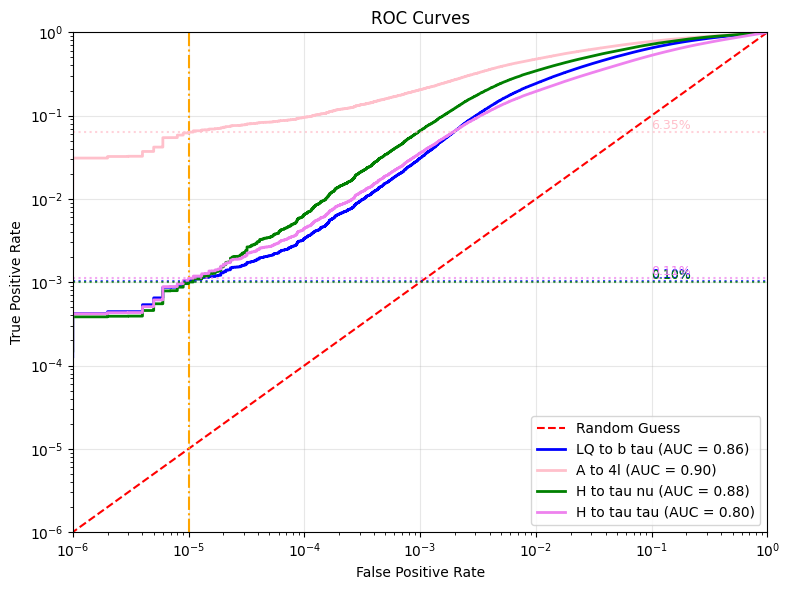

In [ ]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.axvline(1e-5, color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")

# Add horizontal lines and text for TPR at FPR=1e-5 for each signal
for fpr, tpr, color, label in [
   (fpr_lq, tpr_lq, "blue", "LQ to b tau"),
   (fpr_a4l, tpr_a4l, "pink", "A to 4l"),
   (fpr_htnu, tpr_htnu, "green", "H to tau nu"),
   (fpr_htt, tpr_htt, "violet", "H to tau tau"),
]:
   # Find the TPR at FPR closest to 1e-5
   idx = np.searchsorted(fpr, 1e-5, side="right")
   if idx >= len(tpr):
      idx = -1
   tpr_val = tpr[idx]
   plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color, linestyle=":", alpha=0.7)
   plt.text(1e-1, tpr_val, f"{tpr_val*100:.2f}%", color=color, va="bottom", fontsize=9)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()